<h4 style ="text-align:center"> LIBRERIE

In [1]:
import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.patches import Rectangle

<h4 style ="text-align:center"> PARAMETRI

In [2]:
# spazio
L = 50.0
N = 200
dx = L / N
l0 = 0.2998

# vento adim.
wcost = 300
wx = np.full((N, N), wcost, dtype = float)
wx_piatto = wx.flatten()
wy = np.full((N, N), wcost, dtype = float)
wy_piatto = wy.flatten()
alphax = np.max(wx)
alphay = np.max(wy)

# parametri
h = (1/(2*(dx**2)))
qreact = 1.0
gamma = (3+np.sqrt(3))/6
eps = 0.03
u_pc = 0
kappa = 0.1

# tempo, se w cambia nel tempo và ricalcolato il dt
t0 = 8986.8
time = 0.06
dt = (0.12*dx) / (2*np.sqrt(wcost**2 + wcost**2))
timestep = int(time / dt) + 1
print("dt = ",dt)
print("numero di timestep: ",timestep)

# dissipazione
A = sp.diags(np.full((N*N),1e-3), shape = (N*N, N*N), dtype = float)

dt =  3.535533905932737e-05
numero di timestep:  1698


<h4 style ="text-align:center">CONDIZIONI A CONTORNO</h4>

In [3]:
# temperatura adim. e combustibile adim.
u = np.full((N, N, timestep), 0.0, dtype = float)
inizio_quadrato, fine_quadrato = 16, 48
u[inizio_quadrato:fine_quadrato, inizio_quadrato:fine_quadrato, 0] = 31.0

v = np.full((N, N, timestep), 0.7, dtype = float)
#v[:,100:, 0] = 0.70
#noise = np.random.uniform(-0.025, 0.025, (N, N))
#v[:, :, 0] += noise
# frangifuoco
#v[:,75:100, 0] = 0.0

<h4 style ="text-align:center"> FUNZIONI AUSILIARIE

In [4]:
# attributi: da f-2 a f+2
def WENO(f1, f2, f3, f4, f5):
    b1 = (13/12) * (f1 - 2*f2 + f3)**2 + (1/4) * (f1 - 4*f2 + 3*f3)**2
    b2 = (13/12) * (f2 - 2*f3 + f4)**2 + (1/4) * (f2 - f4)**2
    b3 = (13/12) * (f3 - 2*f4 + f5)**2 + (1/4) * (3*f3 - 4*f4 + f5)**2

    a1 = 0.1 / ( (1e-6 + b1)**2 )
    a2 = 0.6 / ( (1e-6 + b2)**2 )
    a3 = 0.3 / ( (1e-6 + b3)**2 )

    #pesi
    w1 = a1 / (a1 + a2 + a3)
    w2 = a2 / (a1 + a2 + a3)    
    w3 = a3 / (a1 + a2 + a3)

    return (w1 * ( (1/3)*f1 - (7/6)*f2 + (11/6)*f3 ) +
            w2 * ( (-1/6)*f2 + (5/6)*f3 + (1/3)*f4 ) +
            w3 * ( (1/3)*f3 + (5/6)*f4 - (1/6)*f5 ) )

In [5]:
# calcola C,D,G con la temperatura esplicita
def calcola_C_D_G(u_piatto, u_table):
    # coefficiente di convezione matriciale
    C = np.zeros((N,N), dtype = float)
    
    # parte del coefficiente di diffusione
    K = kappa*((1 + eps*u_piatto)**3) + 1.0

    # vettori utili al WENO, i punti ai bordi sono 0 per la condizione zero-flux
    f_x = np.zeros((N, N), dtype = float)
    f_y = np.zeros((N, N), dtype = float)
    f_x[3:-3, 3:-3] = wx[3:-3, 3:-3]*u_table[3:-3, 3:-3]
    f_x_plus = (1/2) * (f_x + alphax * u_table)
    f_x_minus = (1/2) * (f_x - alphax * u_table)
    f_y[3:-3, 3:-3] = wy[3:-3, 3:-3] * u_table[3:-3, 3:-3]
    f_y_plus = (1/2) * (f_y + alphay * u_table)
    f_y_minus = (1/2) * (f_y - alphay * u_table)


    # calcolo della matrice di avvezione (split dei flussi)
    C[3:-3, 3:-3] = (-1/dx) * (WENO(f_x_plus[1:-5, 3:-3], f_x_plus[2:-4, 3:-3], f_x_plus[3:-3, 3:-3], f_x_plus[4:-2, 3:-3], f_x_plus[5:-1, 3:-3]) + 
                               WENO(f_x_minus[6:, 3:-3], f_x_minus[5:-1, 3:-3], f_x_minus[4:-2, 3:-3], f_x_minus[3:-3, 3:-3], f_x_minus[2:-4, 3:-3]))
            
    C[3:-3, 3:-3] += (1/dx) * (WENO(f_x_plus[0:-6, 3:-3], f_x_plus[1:-5, 3:-3], f_x_plus[2:-4, 3:-3], f_x_plus[3:-3, 3:-3], f_x_plus[4:-2, 3:-3]) + 
                               WENO(f_x_minus[5:-1, 3:-3], f_x_minus[4:-2, 3:-3], f_x_minus[3:-3, 3:-3], f_x_minus[2:-4, 3:-3], f_x_minus[1:-5, 3:-3]))

    C[3:-3, 3:-3] += (-1/dx) * (WENO(f_y_plus[3:-3, 1:-5], f_y_plus[3:-3, 2:-4], f_y_plus[3:-3, 3:-3], f_y_plus[3:-3, 4:-2], f_y_plus[3:-3, 5:-1]) + 
                               WENO(f_y_minus[3:-3, 6:], f_y_minus[3:-3, 5:-1], f_y_minus[3:-3, 4:-2], f_y_minus[3:-3, 3:-3], f_y_minus[3:-3, 2:-4]))
            
    C[3:-3, 3:-3] += (1/dx) * (WENO(f_y_plus[3:-3, 0:-6], f_y_plus[3:-3, 1:-5], f_y_plus[3:-3, 2:-4], f_y_plus[3:-3, 3:-3], f_y_plus[3:-3, 4:-2]) + 
                               WENO(f_y_minus[3:-3, 5:-1], f_y_minus[3:-3, 4:-2], f_y_minus[3:-3, 3:-3], f_y_minus[3:-3, 2:-4], f_y_minus[3:-3, 1:-5]))
    
    # parte del termine di Arrhenius
    G = sp.diags(((np.exp(u_piatto/(1 + eps * u_piatto)))*((u_piatto >= u_pc).astype(np.float64))), shape = (N*N, N*N), dtype = float)
    
    # calcolo diagonali della matrice di diffusione
    diag_main = -h * (np.concatenate(([0], K[:-1])) + np.concatenate((K[1:], [0])) + 
                      np.concatenate((np.zeros(N), K[:-N])) + np.concatenate((K[N:], np.zeros(N))) + 
                      4*K)
    
    val_est   = h * (K[:-1] + K[1:]) # k=1
    val_ovest = h * (K[:-1] + K[1:]) # k=-1
    
    # eliminiamo i termini fantasma
    val_est[N-1::N]   = 0.0
    val_ovest[N-1::N] = 0.0

    val_nord = h * (K[N:] + K[:-N]) # k=N
    val_sud  = h * (K[:-N] + K[N:]) # k=-N

    # matrice di diffusione
    D = sp.diags([val_sud, val_ovest, diag_main, val_est, val_nord], 
                 offsets=[-N, -1, 0, 1, N], shape=(N*N, N*N), format='csr')
    
    return C, D, G


<h4 style ="text-align:center"> INTEGRAZIONE NEL TEMPO

In [6]:
# integrazione nel tempo
# si usa u_esplicito come predictor, u_implicito come corrector 
for n in range(timestep-1):
    u_piatto = u[:, :, n].flatten()
    v_piatto = v[:, :, n].flatten()
    print("n = ",n)

    # runge-kutta 1o step
    u_esp_1 = u_piatto.copy()
    u_impl_1 = u_piatto.copy()
    v_1 = v_piatto.copy()

    C, D, G = calcola_C_D_G(u_esp_1, u_esp_1.reshape((N, N)))
    K_v_1 = - (eps/qreact)*(v_1 * G.diagonal())/(1 + (eps/qreact)*(dt*gamma*G.diagonal()))
    K_u_1 = sp.linalg.spsolve(sp.identity(N*N) - dt*gamma*(D - A), C.flatten() + (D - A) @ (u_impl_1) + (v_1 + dt*gamma*K_v_1) @ G)
    
    # runge-kutta 2o step
    u_esp_2 = u_piatto + dt * K_u_1
    u_impl_2 = u_piatto + dt * (1 - 2*gamma) * K_u_1
    v_2 = v_piatto + dt * (1 - 2*gamma) * K_v_1

    C, D, G = calcola_C_D_G(u_esp_2, u_esp_2.reshape((N, N)))
    K_v_2 = - (eps/qreact)*(v_2 * G.diagonal())/(1 + (eps/qreact)*(dt*gamma*G.diagonal()))
    K_u_2 = sp.linalg.spsolve(sp.identity(N*N) - dt*gamma*(D - A), C.flatten() + (D - A) @ (u_impl_2) + (v_2 + dt*gamma*K_v_2) @ G)
    
    # runge-kutta approx time-step successivo
    u_nuova = u_piatto + dt * (1/2 * K_u_1 + 1/2 * K_u_2)
    v_nuova = v_piatto + dt * (1/2 * K_v_1 + 1/2 * K_v_2)

    u[:, :, n+1] = u_nuova.reshape(N, N)
    v[:, :, n+1] = v_nuova.reshape(N, N)

n =  0
n =  1
n =  2
n =  3
n =  4
n =  5
n =  6
n =  7
n =  8
n =  9
n =  10
n =  11
n =  12
n =  13
n =  14
n =  15
n =  16
n =  17
n =  18
n =  19
n =  20
n =  21
n =  22
n =  23
n =  24
n =  25
n =  26
n =  27
n =  28
n =  29
n =  30
n =  31
n =  32
n =  33
n =  34
n =  35
n =  36
n =  37
n =  38
n =  39
n =  40
n =  41
n =  42
n =  43
n =  44
n =  45
n =  46
n =  47
n =  48
n =  49
n =  50
n =  51
n =  52
n =  53
n =  54
n =  55
n =  56
n =  57
n =  58
n =  59
n =  60
n =  61
n =  62
n =  63
n =  64
n =  65
n =  66
n =  67
n =  68
n =  69
n =  70
n =  71
n =  72
n =  73
n =  74
n =  75
n =  76
n =  77
n =  78
n =  79
n =  80
n =  81
n =  82
n =  83
n =  84
n =  85
n =  86
n =  87
n =  88
n =  89
n =  90
n =  91
n =  92
n =  93
n =  94
n =  95
n =  96
n =  97
n =  98
n =  99
n =  100
n =  101
n =  102
n =  103
n =  104
n =  105
n =  106
n =  107
n =  108
n =  109
n =  110
n =  111
n =  112
n =  113
n =  114
n =  115
n =  116
n =  117
n =  118
n =  119
n =  120
n =  121
n =  122
n =

<h4 style ="text-align:center"> GRAFICI

In [7]:
# Conversione in unità reali

print("tempo reale = ", (time*t0)/60, " minuti")
print("regione di spazio = ", L*l0)
print("velocità vento = ", (l0/t0)*np.sqrt(2*(wcost**2)), " m/s")

tempo reale =  8.986799999999999  minuti
regione di spazio =  14.99
velocità vento =  0.014153465950041862  m/s


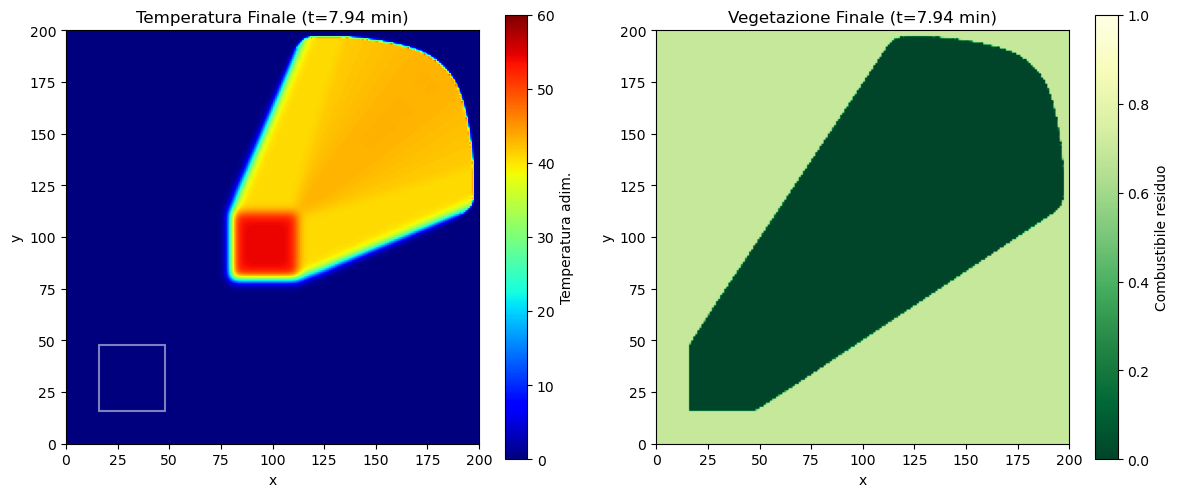

In [8]:
ts = 1500
tentativo = 1

# posizione fuoco all'inizio della simulazione
rect = Rectangle((inizio_quadrato, inizio_quadrato), fine_quadrato-inizio_quadrato, fine_quadrato-inizio_quadrato, linewidth=1.5, edgecolor='white', facecolor='none', label = "punto iniziale", alpha =0.5)

# valori a ts
u_final = u[:, :, ts].reshape((N, N))
v_final = v[:, :, ts].reshape((N, N))

# grafico
plt.figure(figsize=(12, 5))
# --- PLOT TEMPERATURA (u) ---
plt.subplot(1, 2, 1)
plt.imshow(u_final, cmap='jet', origin='lower', extent=[0, N, 0, N], vmin =0, vmax = 60)
plt.colorbar(label='Temperatura adim.')
plt.title(f'Temperatura Finale (t={((ts*dt*t0)/60):.2f} min)')
plt.xlabel('x')
plt.ylabel('y')
plt.gca().add_patch(rect)
# --- PLOT COMBUSTIBILE (v) ---
plt.subplot(1, 2, 2)
plt.imshow(v_final, cmap='YlGn_r', origin='lower', extent=[0, N, 0, N], vmin=0, vmax=1)
plt.colorbar(label='Combustibile residuo')
plt.title(f'Vegetazione Finale (t={((ts*dt*t0)/60):.2f} min)')
plt.xlabel('x')
plt.ylabel('y')
plt.savefig(f'grafico_{tentativo}_{((ts*dt*t0)/60):.2f}.png', dpi=300)

plt.tight_layout()
plt.show()

<h4 style ="text-align:center"> ANIMAZIONE

In [9]:
# Posizione fuoco all'inizio della simulazione
rect = Rectangle((inizio_quadrato, inizio_quadrato), fine_quadrato-inizio_quadrato, fine_quadrato-inizio_quadrato, linewidth=1.5, edgecolor='white', facecolor='none', label = "punto iniziale", alpha = 0.5)
fig, ax = plt.subplots(figsize=(6, 6))
ax.add_patch(rect)

# Per velocizzare l'animazione
salto = 5
u_veloce = u[:, :, ::salto]
vmin = 0
vmax = 60


# Plot
im = ax.imshow(u_veloce[:, :, 0], cmap='jet', origin='lower', 
               extent=[0, N, 0, N], vmin=vmin, vmax=vmax, interpolation='nearest')

fig.colorbar(im, ax=ax, label='Temperatura adim.')
tx = ax.set_title('Frame 0')
def update(frame):
    # Aggiorna i dati dell'immagine con il timestep corrente
    im.set_data(u_veloce[:, :, frame])
    tx.set_text(f'Tempo t={((frame*salto*dt*t0)/60):.2f} min')
    return im, tx

ani = animation.FuncAnimation(fig, update, frames=u_veloce.shape[2], 
                              interval=17, blit=True)
plt.close() 

print("Salvataggio GIF in corso...")
ani.save(f'gif_{tentativo}_fuoco.gif', writer='pillow', fps=60)
print(f"GIF salvata come 'gif_{tentativo}_fuoco.gif'")

Salvataggio GIF in corso...
GIF salvata come 'gif_1_fuoco.gif'


In [10]:
# Imposta figure e v
fig, ax = plt.subplots(figsize=(6, 6))
u_veloce = v[:, :, ::salto]
vmin = 0
vmax = 1

# Plot
im = ax.imshow(u_veloce[:, :, 0], cmap='YlGn_r', origin='lower', 
               extent=[0, N, 0, N], vmin=vmin, vmax=vmax, interpolation='nearest')

fig.colorbar(im, ax=ax, label='Frazione di carburante')
tx = ax.set_title('Frame 0')
def update(frame):
    # Aggiorna i dati dell'immagine con il timestep corrente
    im.set_data(u_veloce[:, :, frame])
    tx.set_text(f'Tempo t={((frame*salto*dt*t0)/60):.2f} min')
    return im, tx

ani = animation.FuncAnimation(fig, update, frames=u_veloce.shape[2], 
                              interval=17, blit=True)
plt.close() 

print("Salvataggio GIF in corso...")
ani.save(f'gif_{tentativo}_carburante.gif', writer='pillow', fps=60)
print(f"GIF salvata come 'gif_{tentativo}_carburante.gif'")

Salvataggio GIF in corso...
GIF salvata come 'gif_1_carburante.gif'


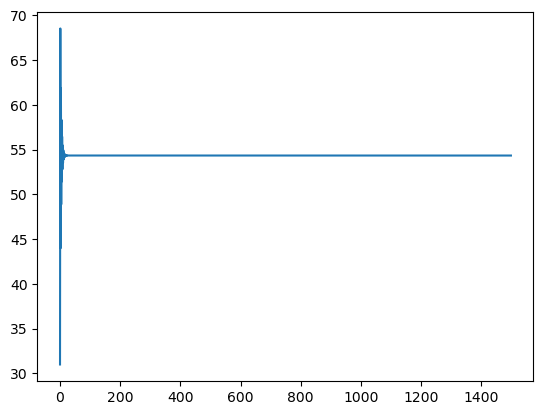

In [11]:
# Controllo massimo temperatura nel tempo
max_u_t = []
for t in range(ts):
    max_u_t.append((u[:,:,t]).max())

plt.plot(range(ts), max_u_t,scaley=[1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20])
plt.show()